# Adding bells and whistles to the training loop

We will cover learning rate warmup, cosine decay, and gradient clipping. We then incorporate these techniques into the training function and pretrain an LLM.

In [1]:
import torch
from src.Architecture.GPTModel import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "embedding_dim": 768,
    "num_heads": 12,
    "num_layers": 12,
    "dropout": 0.1,
    "qkv_bias": False
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query)

In [2]:
file_path = "data/the-verdict.txt"

with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

print("Text Length:", len(text_data))

Text Length: 20479


In [3]:
from src.Utilities.DataProcessing import create_dataloader_v1

train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
torch.manual_seed(123)
train_loader = create_dataloader_v1(
    text_data[:split_idx],
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    number_of_workers=0
)
val_loader = create_dataloader_v1(
    text_data[split_idx:],
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    number_of_workers=0
)

### Learning rate warmup

Implementing a learning rate warmup can stabilize the training of complex models such as LLMs. This process involves gradually increasing the learning rate from a very
low initial value (initial_lr) to a maximum value specified by the user (peak_lr). Starting the training with smaller weight updates decreases the risk of the model encountering large, destabilizing updates during its training phase.

Suppose we plan to train an LLM for 15 epochs, starting with an initial learning rate of 0.0001 and increasing it to a maximum learning rate of 0.01:

In [4]:
n_epochs = 15
initial_lr = 0.0001
peak_lr = 0.01

The number of warmup steps is usually set between 0.1% and 20% of the total number of steps, which we can calculate as follows:

In [5]:
total_steps = len(train_loader) * n_epochs
warmup_steps = int(0.2 * total_steps)
print("Warmup steps: ", warmup_steps)
print("Total steps: ", total_steps)
print("Warmup step percentage: ",  warmup_steps / total_steps * 100, "%")

Warmup steps:  27
Total steps:  135
Warmup step percentage:  20.0 %


Next, we implement a simple training loop template to illustrate this warmup process:

In [6]:
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)
lr_increment = (peak_lr - initial_lr) / warmup_steps   # this is the learning rate increment per warmup step
global_step = -1
track_lrs = []
for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1

        if global_step < warmup_steps:  # update learning rate if still during warmup
            lr = initial_lr + global_step * lr_increment
        else:
            lr = peak_lr

        for param_group in optimizer.param_groups:  # applies the calculated learning rate to the optimizer
            param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])

After running the preceding code, we visualize how the learning rate was changed by the training loop to verify that the learning rate warmup works as intended:

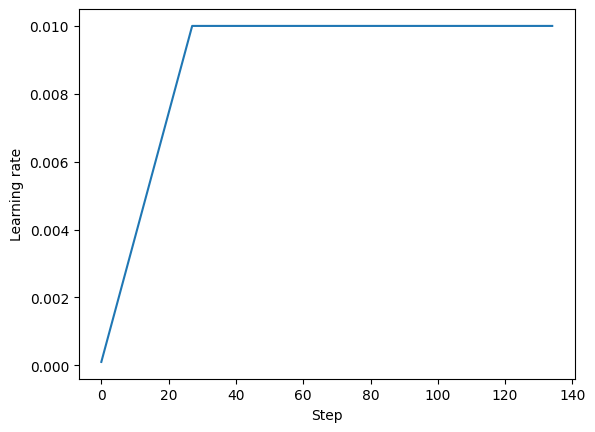

In [7]:
import matplotlib.pyplot as plt
plt.ylabel("Learning rate")
plt.xlabel("Step")
total_training_steps = len(train_loader) * n_epochs
plt.plot(range(total_training_steps), track_lrs);
plt.show()

The resulting plot shows that the learning rate starts with a low value and increases for 20 steps until it reaches the maximum value after 20 steps. Next, we will modify the learning rate further so that it decreases after reaching the maximum learning rate, which further helps improve the model training

### Cosine decay

Another widely adopted technique for training complex deep neural networks and LLMs is cosine decay. This method modulates the learning rate throughout the training
epochs, making it follow a cosine curve after the warmup stage.

In its popular variant, cosine decay reduces (or decays) the learning rate to nearly zero, mimicking the trajectory of a half-cosine cycle. The gradual learning decrease in
cosine decay aims to decelerate the pace at which the model updates its weights. This is particularly important because it helps minimize the risk of overshooting the loss minima during the training process, which is essential for ensuring the stability of the training during its later phases.

We can modify the training loop template by adding cosine decay:

In [8]:
import math
min_lr = 0.1 * initial_lr
track_lrs = []
lr_increment = (peak_lr - initial_lr) / warmup_steps
global_step = -1

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1

        if global_step < warmup_steps:  # apply learning rate warmup
            lr = initial_lr + global_step * lr_increment
        else:
            # uses cosine annealing decay after warmup
            progress = ((global_step - warmup_steps) /
                        (total_training_steps - warmup_steps))
            lr = min_lr + (peak_lr - min_lr) * 0.5 * (
                1 + math.cos(math.pi * progress))
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])

Again, to verify that the learning rate has changed as intended, we plot the learning rate:

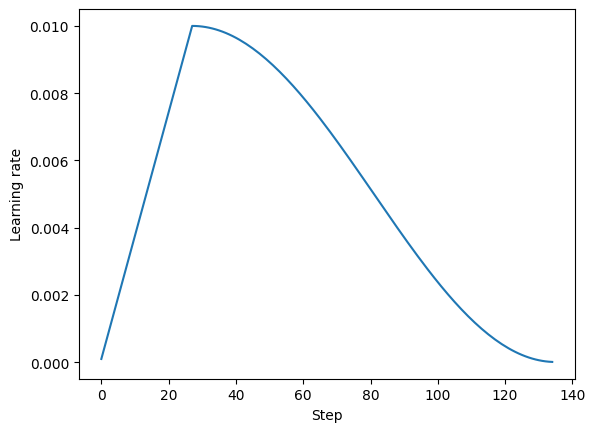

In [9]:
plt.ylabel("Learning rate")
plt.xlabel("Step")
plt.plot(range(total_training_steps), track_lrs)
plt.show()

The resulting learning rate plot shows that the learning rate starts with a linear warmup phase, which increases for 20 steps until it reaches the maximum value after 20 steps. After the 20 steps of linear warmup, cosine decay kicks in, reducing the learning rate gradually until it reaches its minimum.

### Gradient clipping

Gradient clipping is another important technique for enhancing stability during LLM training. This method involves setting a threshold above which gradients are down
scaled to a predetermined maximum magnitude. This process ensures that the updates to the model’s parameters during backpropagation stay within a manageable range.

For example, applying the max_norm=1.0 setting within PyTorch’s clip_grad_norm_ function ensures that the norm of the gradients does not surpass 1.0. Here, the
term “norm” signifies the measure of the gradient vector’s length, or magnitude, within the model’s parameter space, specifically referring to the L2 norm, also known
as the Euclidean norm.

In mathematical terms, for a vector v composed of components v = [v1, v2, ..., vn], the L2 norm is:

$$
|v|_2 = \sqrt{v_1^2 + v_2^2 + ... + v_n^2}
$$

This calculation method is also applied to matrices. For instance, consider a gradient matrix given by:

$$
G = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}
$$

If we want to clip these gradients to a max_norm of 1, we first compute the L2 norm of these gradients, which is:

$$
|G|_2 = \sqrt{1^2 + 2^2 + 2^2 + 4^2} = \sqrt{25} = 5
$$

Given that |G|2 = 5 exceeds our max_norm of 1, we scale down the gradients to ensure their norm equals exactly 1. This is achieved through a scaling factor, calculated as
max_norm/|G|2 = 1/5. Consequently, the adjusted gradient matrix G' becomes:

$$
G' = \frac{1}{5} \times G = \begin{bmatrix} \frac{1}{5} & \frac{2}{5} \\ \frac{2}{5} & \frac{4}{5} \end{bmatrix}
$$

To illustrate this gradient clipping process, we begin by initializing a new model and calculating the loss for a training batch, similar to the procedure in a standard training loop:

In [10]:
from src.Utilities.TrainingUtilities import calc_loss_batch

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
loss = calc_loss_batch(input_batch, target_batch, model, device)
loss.backward()

In [11]:
def find_highest_gradient(model):
    """
    Finds the largest gradient value in the model's parameters.
    :param model:
    :return:
    """
    max_grad = None
    for param in model.parameters():
        if param.grad is not None:
            grad_values = param.grad.data.flatten()
            max_grad_param = grad_values.max()
            if max_grad is None or max_grad_param > max_grad:
                max_grad = max_grad_param
    return max_grad

print(find_highest_gradient(model))

tensor(0.0457, device='cuda:0')


Let’s now apply gradient clipping and see how this affects the largest gradient value:

In [12]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
print(find_highest_gradient(model))

tensor(0.0205, device='cuda:0')


The largest gradient value after applying the gradient clipping with the max norm of 1 is substantially smaller than before:

### The modified training function

Finally, we improve the train_model_simple training function (see chapter 5) by adding the three concepts introduced herein: linear warmup, cosine decay, and gradient clipping. Together, these methods help stabilize LLM training.

In [13]:
from src.Utilities.TrainingUtilities import train_model

In [14]:
import tiktoken
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
peak_lr = 0.001
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)
tokenizer = tiktoken.get_encoding("gpt2")
n_epochs = 15
train_losses, val_losses, tokens_seen, lrs = train_model(
    model, train_loader, val_loader, optimizer, device, n_epochs=n_epochs,
    eval_freq=5, eval_iter=1, start_context="Every effort moves you",
    tokenizer=tokenizer, warmup_steps=warmup_steps,
    initial_lr=1e-5, min_lr=1e-5
)

Ep 1 (Iter 000000): Train loss 10.969, Val loss 10.938
Ep 1 (Iter 000005): Train loss 9.338, Val loss 9.462
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 (Iter 000010): Train loss 7.821, Val loss 8.188
Ep 2 (Iter 000015): Train loss 6.341, Val loss 6.892
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 3 (Iter 000020): Train loss 6.084, Val loss 6.597
Ep 3 (Iter 000025): Train loss 5.669, Val loss 6.796
Every effort moves you, the of the of the of the of the, the of the of the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the
Ep 4 (Iter 000030): Train loss 5.836, Val loss 6.827
Ep 4 (Iter 000035): Train loss 5.984, Val loss 6.956
Every effort moves you aisis a G                                             
Ep 5 (Iter 000040): Train loss 7.048, Val loss 8.044
Every effort moves you,, and, a. I, the. I, the. I,,,, the. I, a. I,,, the a. I, the,,, the. I,,,,,, the,,
Ep 6 (Iter 000045): Train loss

Like pretraining, the model begins to overfit after a few epochs since it is a very small dataset, and we iterate over it multiple times. Nonetheless, we can see that the function is working since it minimizes the training set loss.

Readers are encouraged to train the model on a larger text dataset and compare the results obtained with this more sophisticated training function to the results that can be obtained with the train_model_simple function.

Note: Warmup, cosine annealing, and gradient clipping all slow the learning process at different points of training. This means that training may take longer to achieve the same level of loss. However, the goal is to find better optimized valleys during gradient decent. The goal is not to increase training speed, but rather, more stable exploration of the possibility space.

After 15 epochs, the training loss was 2.094, whereas the validation loss is stabilizing around 6.14 using our improved training loop.

In comparison, using the simple training loop after 10 epochs, our training loss was 0.77, and validation loss was 6.5. Our validation loss did get close to 6.14 around epoch 6 but then hopped around and started to increase as we overfit the training data.